In [ ]:
#Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [85]:
#Extract the csv file

df=pd.read_csv('student_performances.csv')

In [86]:
df

,study_hours,exam_score
0,4.4,59
1,9.6,98
2,7.6,82
3,6.4,69
4,2.4,42
...,...,...
495,4.2,55
496,6.3,69
497,1.7,44
498,9.8,95


In [87]:
#Check the realtionship between columns before training the model

df.corr()

,study_hours,exam_score
study_hours,1.00000,0.98577
exam_score,0.98577,1.00000


* The realtion between the feature columns are strongly co-realated

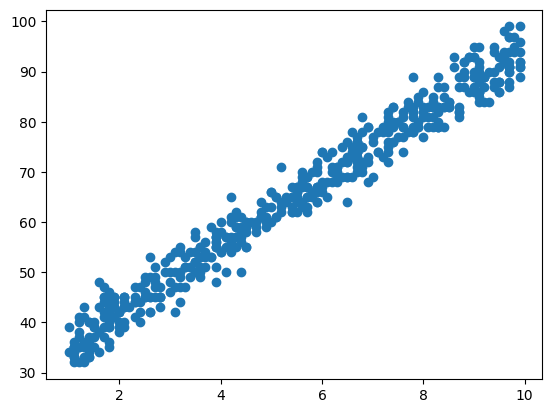

In [88]:
plt.scatter(data=df,x='study_hours',y='exam_score')

* The relation is highly co-related and it follows the straight line and the columns are directly proportional to each other

In [89]:
#Segregation of feature and target columns in a variables
x=df.drop(columns='exam_score')
y=df['exam_score']

In [90]:
#Train Test Split
# Note-->>We should not train the model with 100% of  data instead we train with 80% for training and 
# 20% for testing whether the model performance is good or bad

xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)


In [91]:
#Model Creation

model=LinearRegression()

In [92]:
#Model Training

model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [93]:
#Model Prediction for train data
train_pred=model.predict(xtrain)

In [94]:
#Model Prediction for train data
test_pred=model.predict(xtest)

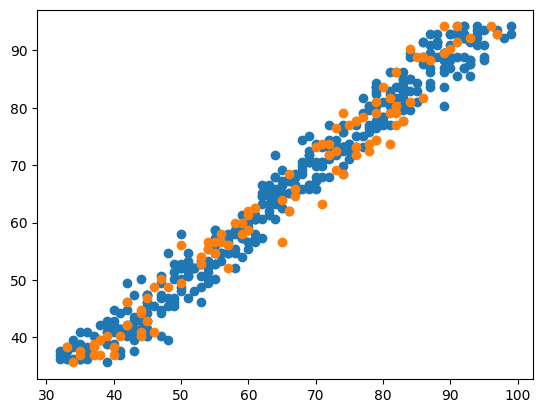

In [95]:
#Model Evaluation

plt.scatter(ytrain,train_pred)
plt.scatter(ytest,test_pred)


* The model captured the patterns very good

In [96]:
#Train data errors

train_errors=ytrain-train_pred
print(train_errors)


249   -5.283644
433    3.464706
19     2.277619
322   -6.438493
332   -0.270782
         ...   
106    0.038915
270   -0.651388
348    3.013107
435    3.929251
102    4.961491
Name: exam_score, Length: 400, dtype: float64


In [97]:
#Test data errors

test_errors=ytest-test_pred
print(test_errors)

361   -2.780429
73    -3.651388
374   -1.561102
155   -3.090125
104   -0.573964
         ...   
347   -5.244974
86    -5.044941
75    -0.044941
438   -1.728813
15    -1.799806
Name: exam_score, Length: 100, dtype: float64


In [98]:
#Model Evaluation using the Regresion Metrics(Train Data)
print('mae_train',mean_absolute_error(ytrain,train_pred))
print('rmse_train',root_mean_squared_error(ytrain,train_pred))
print('r2_train',r2_score(ytrain,train_pred))

mae_train 2.4056006060220283
rmse_train 2.992145676913155
r2_train 0.9724205636181671


In [99]:
#Model Evaluation using the Regresion Metrics(Test Data)
print('mae_test',mean_absolute_error(ytest,test_pred))
print('rmse_test',root_mean_squared_error(ytest,test_pred))
print('r2_test',r2_score(ytest,test_pred))

mae_test 2.5033339387700453
rmse_test 3.10347828954141
r2_test 0.9687181224150238


### The model is Goodfit 
*It captures the patterns and performance is very good with less errors 

In [102]:
#Model Prediction Using new input
new_input=[[3],[10]]
model.predict(new_input)

c:\Users\Ubaidur Rahman\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([48.77399752, 94.83847598])